In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
from sklearn.model_selection import train_test_split
from scipy import stats
from scipy.stats import epps_singleton_2samp
from PIL import Image
from train_test_helper import optimize_split
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


COUNTS
Total RBC count: 4155
Total WBC count: 372
Total Platelet count: 361
Clearly there is a class imbalance in the dataset. RBCs are the most abundant, followed by WBCs and Platelets.


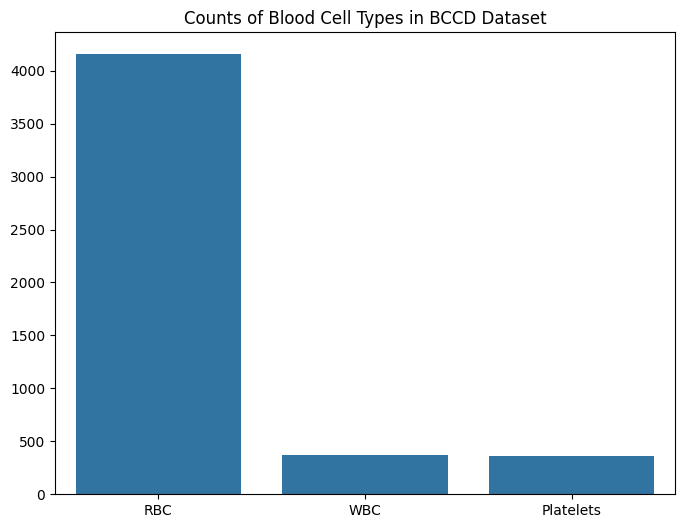

IMAGES CONTAINING EACH BLOOD CELL TYPE
Images with RBCs: 349
Images with WBCs: 358
Images with Platelets: 201
Images with no RBCs: 15
Images with no WBCs: 6
Images with no Platelets: 163


Text(0.5, 1.0, 'Distribution of Platelet Counts per Image')

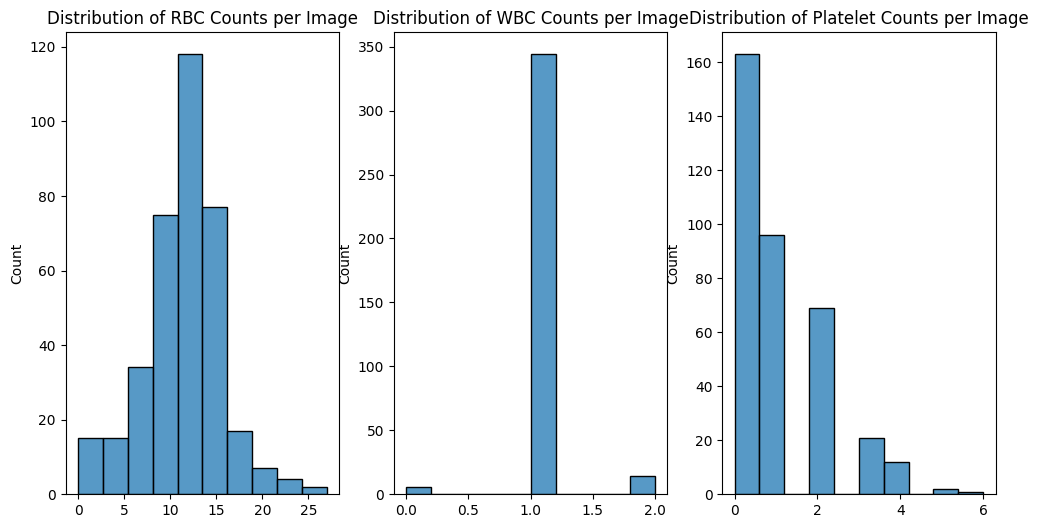

In [9]:
# Getting Annotations and Exploring Blood Cell counts. This is to find out if the dataset is balanced or not.
anno_dir = '../data/BCCD/Annotations/'
files_in_anno_dir = os.listdir(anno_dir)

# Parsing the XML files and converting them to JSON format for easier analysis
json_data = []
for f in files_in_anno_dir:
    with open(os.path.join(anno_dir, f)) as xml_file:
        json_data.append({f[:-4]: {}})
        tree = ET.parse(xml_file)
        root = tree.getroot()
        names = []
        rbc_count = 0
        wbc_count = 0
        platelet_count = 0
        size = root.findall('size')
        for i in size:
            width = i.find('width').text
            height = i.find('height').text
        for b in root.findall('object'):
            name = b.find('name').text
            if name.lower() == 'RBC'.lower():
                rbc_count += 1
                new_key = name + str(rbc_count)
            elif name.lower() == 'WBC'.lower():
                wbc_count += 1
                new_key = name + str(wbc_count)
            elif name.lower() == 'Platelets'.lower():
                platelet_count += 1
                new_key = name + str(platelet_count)
            bounding_box = b.find('bndbox')
            xmin = int(bounding_box.find('xmin').text)
            xmax = int(bounding_box.find('xmax').text)
            ymin = int(bounding_box.find('ymin').text)
            ymax = int(bounding_box.find('ymax').text)
            trunc = int(b.find('truncated').text)
            difficult = int(b.find('difficult').text)
            names.append(name)
            json_data[-1][f[:-4]][new_key] = {
                'name': name,
                'xmin': xmin,
                'xmax': xmax,
                'ymin': ymin,
                'ymax': ymax,
                'truncated': trunc,
                'difficult': difficult
            }
        json_data[-1][f[:-4]]['counts'] = {
            'RBC': rbc_count,
            'WBC': wbc_count,
            'Platelets': platelet_count
        }

#Extracting the counts of each blood cell type from the JSON data
rbc_counts = []
wbc_counts = []
platelet_counts = []
for data in json_data:
    for key in data.keys():
        rbc_counts.append(data[key]['counts']['RBC'])
        wbc_counts.append(data[key]['counts']['WBC'])
        platelet_counts.append(data[key]['counts']['Platelets'])
rbc_sum = np.sum(rbc_counts)
wbc_sum = np.sum(wbc_counts)
platelet_sum = np.sum(platelet_counts)

print('COUNTS')
print(f'Total RBC count: {rbc_sum}')
print(f'Total WBC count: {wbc_sum}')
print(f'Total Platelet count: {platelet_sum}')

# Visualizing the TOTAL counts of each blood cell type using a bar plot
cell_types = ['RBC', 'WBC', 'Platelets']
counts = [rbc_sum, wbc_sum, platelet_sum]
plt.figure(figsize=(8, 6))
sns.barplot(x=cell_types, y=counts)
plt.title('Counts of Blood Cell Types in BCCD Dataset')
print("Clearly there is a class imbalance in the dataset. RBCs are the most abundant, followed by WBCs and Platelets.")
plt.show()

#However, this does make sense...there should be more RBCs than WBCs and Platelets in a blood smear. A better
# way to look at the data is to see how many images contain each type of blood cell. This will give us a better idea of how
# balanced the dataset is in terms of the number of images containing each type of blood cell.

images_with_rbc = 0
images_with_wbc = 0
images_with_platelets = 0
images_with_no_rbc = 0
images_with_no_wbc = 0
images_with_no_platelets = 0
for data in json_data:
    for key in data.keys():
        if data[key]['counts']['RBC'] > 0:
            images_with_rbc += 1
        if data[key]['counts']['WBC'] > 0:
            images_with_wbc += 1
        if data[key]['counts']['Platelets'] > 0:
            images_with_platelets += 1
        if data[key]['counts']['RBC'] == 0:
            images_with_no_rbc += 1
        if data[key]['counts']['WBC'] == 0:
            images_with_no_wbc += 1
        if data[key]['counts']['Platelets'] == 0:
            images_with_no_platelets += 1

print('IMAGES CONTAINING EACH BLOOD CELL TYPE')
print(f'Images with RBCs: {images_with_rbc}')
print(f'Images with WBCs: {images_with_wbc}')
print(f'Images with Platelets: {images_with_platelets}')
print(f'Images with no RBCs: {images_with_no_rbc}')
print(f'Images with no WBCs: {images_with_no_wbc}')
print(f'Images with no Platelets: {images_with_no_platelets}')

# in this piece of code, I plot the distribution of RBC, WBC, and Platelet counts per image respectively.
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(rbc_counts, bins=10)
plt.title('Distribution of RBC Counts per Image')
plt.subplot(1, 3, 2)
sns.histplot(wbc_counts, bins=10)
plt.title('Distribution of WBC Counts per Image')
plt.subplot(1, 3, 3)
sns.histplot(platelet_counts, bins=10)
plt.title('Distribution of Platelet Counts per Image')

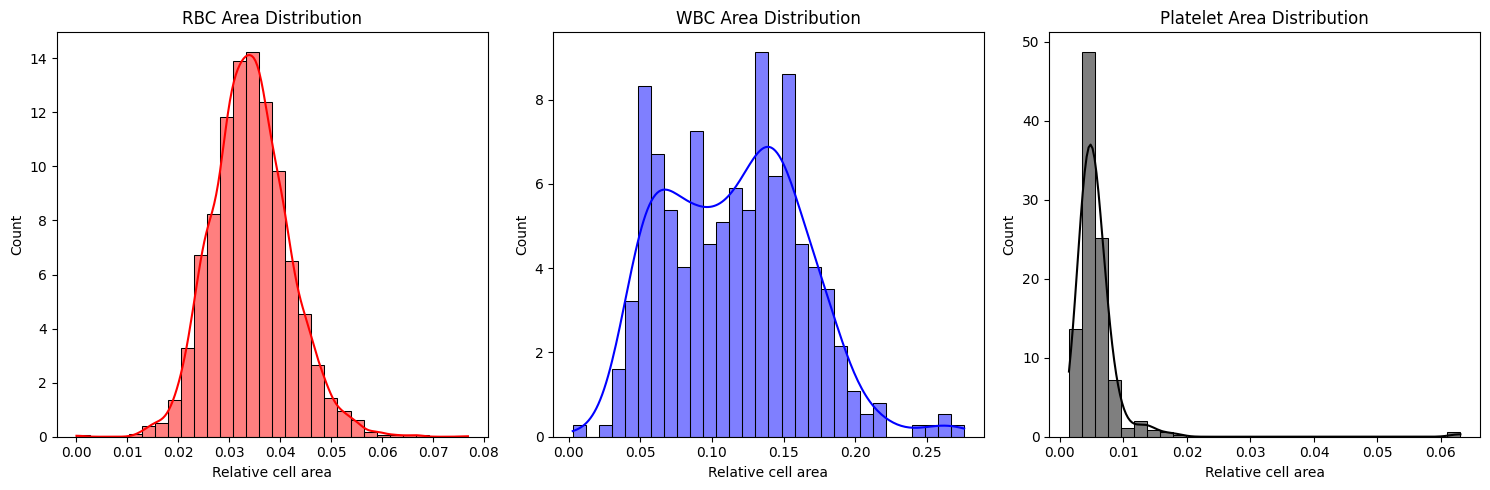

In [10]:
# EDA on cell sizes


jpg_dir = '../data/BCCD/JPEGImages/'
jpgs_in_jpg_dir = os.listdir(jpg_dir)
sizes_dict = {}
for entry in json_data:
    blood_image_name = list(entry.keys())[0]
    sizes_dict[blood_image_name] = {"RBC":[], "WBC":[], "Platelets":[]}
    filename = blood_image_name+".jpg"
    filename = os.path.join(jpg_dir, filename)
    # Load the image
    image = Image.open(filename)

    # Show it
    # plt.figure(figsize=(8, 6))
    # plt.imshow(image)
    # plt.axis("off")
    # plt.title(blood_image_name)
    # plt.show()
    for key, item in entry[blood_image_name].items():
        try:
            cell_type = entry[blood_image_name][key]['name']
            xmin = entry[blood_image_name][key]['xmin']
            xmax = entry[blood_image_name][key]['xmax']
            ymin = entry[blood_image_name][key]['ymin']
            ymax = entry[blood_image_name][key]['ymax']
            pt1 = (xmin, ymin)
            pt2 = (xmin, ymax)
            pt3 = (xmax, ymin)
            pt4 = (xmax, ymax)
            area = (xmax - xmin) * (ymax - ymin)/(image.width*image.height)
            sizes_dict[blood_image_name][cell_type].append(area)
            # print(cell_type)
            if cell_type == "RBC":
                color = 'red'
            elif cell_type == "WBC":
                color = "blue"
            else:
                color = "black"
            # plt.plot([xmin, xmax],[ymin, ymin], color=color)
            # plt.plot([xmax, xmax],[ymin, ymax], color=color)
            # plt.plot([xmin, xmax],[ymax, ymax], color=color)
            # plt.plot([xmin, xmin],[ymax, ymin], color=color)
            
            # plt.text(xmin, ymin - 5, f'{cell_type} Area: {area*1000:.4f}', color=color, fontsize=8) #mult by 1000 just for display
        except KeyError:
            pass
i = 0
all_rbc_areas = []
all_wbc_areas = []
all_platelet_areas = []

for key, item in sizes_dict.items():
    rbc_areas = item['RBC']
    wbc_areas = item['WBC']
    platelet_areas = item['Platelets']
    all_rbc_areas.extend(rbc_areas)
    all_wbc_areas.extend(wbc_areas)
    all_platelet_areas.extend(platelet_areas)


# Plot the distribution of cell areas by type
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(np.asarray(all_rbc_areas), bins=30, kde=True, color='red', stat='percent')
plt.title('RBC Area Distribution')
plt.xlabel('Relative cell area')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.histplot(np.asarray(all_wbc_areas), bins=30, kde=True, color='blue', stat = 'percent')
plt.title('WBC Area Distribution')
plt.xlabel('Relative cell area')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.histplot(np.asarray(all_platelet_areas), bins=30, kde=True, color='black', stat='percent')
plt.title('Platelet Area Distribution')
plt.xlabel('Relative cell area')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Initial train loss: 0.2238
Initial test loss: 0.5167
Initial Combined Loss: 0.7404
START


100%|██████████| 15000/15000 [00:02<00:00, 7257.19it/s]



Final Train Loss: 0.0409
Final Test Loss: 0.0944
Final Combined Loss: 0.1353

P-value for RBC train distribution vs original distribution: 0.999993
P-value for RBC test distribution vs original distribution: 0.999874
p-value not found for train WBC distributions 
p-value not found for test WBC distributions 
P-value for Platelet train distribution vs original distribution: 0.9996
P-value for Platelet test distribution vs original distribution: 0.9871


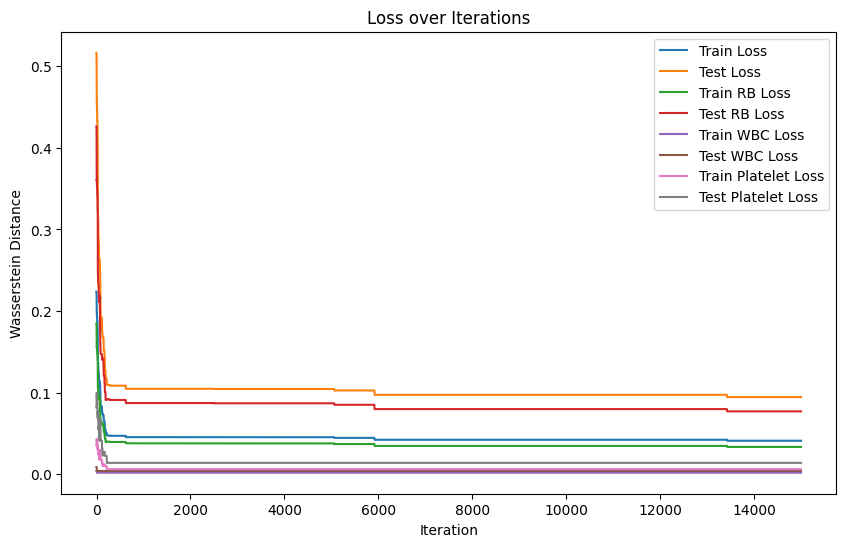

<Figure size 640x480 with 0 Axes>

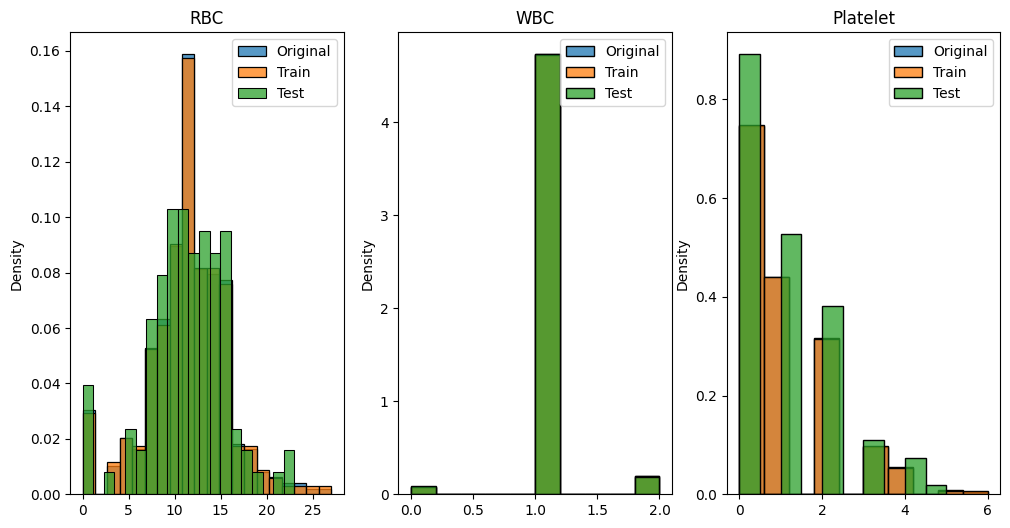

In [12]:
# This cell is a divergence from EDA. This takes what I have learned above from raw cell counts
# and sets up an optimized train/test splitting routine that should have the train/test splits
# have very similar distributions of cell counts per image across each cell type.
# This preserves class integrity across train/test splits (e.g., a truly random split might have few
# to no platelets in test and most of them in train).

train_idx, test_idx = train_test_split(np.arange(len(json_data)), test_size=0.3)
# val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

train_idx = train_idx.tolist()
test_idx = test_idx.tolist()
# val_idx = val_idx.tolist()

train_idx, test_idx, all_train_losses_rb, all_test_losses_rb, all_train_losses_wb, all_test_losses_wb, all_train_losses_pl,\
all_test_losses_pl, all_train_losses, all_test_losses = optimize_split(rbc_counts, wbc_counts, platelet_counts, train_idx, test_idx, n_iterations=15000, verbose=True)


print()
_, p = epps_singleton_2samp(rbc_counts, np.array(rbc_counts)[train_idx])
print(f"P-value for RBC train distribution vs original distribution: {p:4f}")
_, p = epps_singleton_2samp(rbc_counts, np.array(rbc_counts)[test_idx])
print(f"P-value for RBC test distribution vs original distribution: {p:4f}")
try:
    _, p = epps_singleton_2samp(wbc_counts, np.array(wbc_counts)[train_idx])
    print(f"P-value for WBC train distribution vs original distribution: {p:4f}")
except np.linalg.LinAlgError:
    print('p-value not found for train WBC distributions ')

try:
    _, p = epps_singleton_2samp(wbc_counts, np.array(wbc_counts)[test_idx])
    print(f"P-value for WBC test distribution vs original distribution: {p:4f}")
except np.linalg.LinAlgError:
    print('p-value not found for test WBC distributions ')

try:
    _, p = epps_singleton_2samp(platelet_counts, np.array(platelet_counts)[train_idx])
    print(f"P-value for Platelet train distribution vs original distribution: {p:.4f}")
except np.linalg.LinAlgError:
    print('p-value not found for train Platelet distributions ')

try:
    _, p = epps_singleton_2samp(platelet_counts, np.array(platelet_counts)[test_idx])
    print(f"P-value for Platelet test distribution vs original distribution: {p:.4f}")
except np.linalg.LinAlgError:
    print('p-value not found for test Platelet distributions ')

plt.figure(figsize=(10, 6))
plt.plot(all_train_losses, label='Train Loss')
plt.plot(all_test_losses, label='Test Loss')
plt.plot(all_train_losses_rb, label = 'Train RB Loss')
plt.plot(all_test_losses_rb, label = "Test RB Loss")
plt.plot(all_train_losses_wb, label='Train WBC Loss')
plt.plot(all_test_losses_wb, label='Test WBC Loss')
plt.plot(all_train_losses_pl, label='Train Platelet Loss')
plt.plot(all_test_losses_pl, label='Test Platelet Loss')
plt.title('Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Wasserstein Distance')
plt.legend()
plt.show()

# in this piece of code, I plot the distribution of RBC, WBC, and Platelet counts per image respectively.
plt.figure()
fig, axes = plt.subplots(1, 3, figsize=(12,6))

sns.histplot(rbc_counts, bins=20, label = 'Original', stat='density', ax = axes[0])
sns.histplot(np.array(rbc_counts)[train_idx], bins = 20, label= 'Train', stat='density', ax = axes[0])
sns.histplot(np.array(rbc_counts)[test_idx], bins=20, label='Test', stat='density', ax = axes[0])
axes[0].set_title("RBC")
axes[0].legend()

plt.subplot(1,3,2)
sns.histplot(wbc_counts, bins=10, label='Original', stat='density', ax=axes[1])
sns.histplot(np.array(wbc_counts)[train_idx], bins=10, label='Train', stat='density', ax=axes[1])
sns.histplot(np.array(wbc_counts)[test_idx], bins=10, label='Test', stat='density', ax=axes[1])
axes[1].set_title("WBC")
axes[1].legend()

plt.subplot(1,3,3)
sns.histplot(platelet_counts, bins=10, label = 'Original', stat='density', ax=axes[2])
sns.histplot(np.array(platelet_counts)[train_idx], bins=10, label = "Train", stat='density', ax=axes[2])
sns.histplot(np.array(platelet_counts)[test_idx], bins=10, label='Test', stat='density', ax=axes[2])
axes[2].set_title("Platelet")
axes[2].legend()

